# 公式チュートリアル 09 — Spatial Gillespie Method（meso）
> 出典: https://ecell4.e-cell.org/tutorials/tutorial09.html

空間を小立方体（**subvolume**）に分割し、区画ごとに Gillespie＋拡散を回す**メソスコピック**法。
分子の**初期分離**が反応速度に効く（出会うまで拡散が要る）ことを見る。

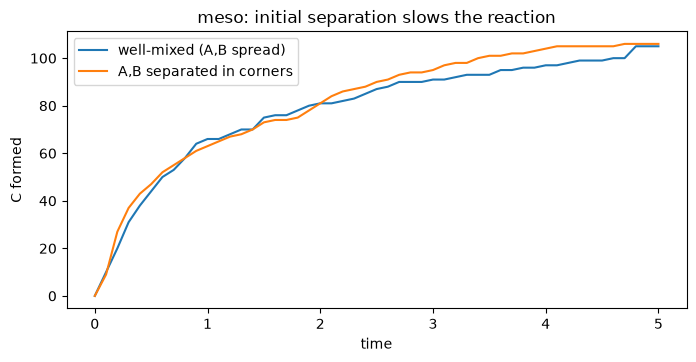

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, matplotlib.pyplot as plt
from ecell4.prelude import *
from ecell4_base import meso

with species_attributes():
    A | B | C | {'D': 1}
with reaction_rules():
    A + B > C | 0.01
m = get_model()

fig, ax = plt.subplots(figsize=(8,3.6))
for sep, lab in [(False,'well-mixed (A,B spread)'), (True,'A,B separated in corners')]:
    w = meso.World(Real3(1,1,1), Integer3(3,3,3)); w.bind_to(m)
    if sep:
        w.add_molecules(Species('A'), 120, Integer3(0,0,0))
        w.add_molecules(Species('B'), 120, Integer3(2,2,2))   # 反対の隅
    else:
        w.add_molecules(Species('A'), 120); w.add_molecules(Species('B'), 120)
    sim = meso.Simulator(w)
    obs = FixedIntervalNumberObserver(0.1, ('C',)); sim.run(5, obs)
    d = np.array(obs.data()); ax.plot(d[:,0], d[:,1], label=lab)
ax.set_xlabel('time'); ax.set_ylabel('C formed'); ax.legend(); ax.set_title('meso: initial separation slows the reaction'); plt.show()

**要点**: `meso.World(edge, Integer3(nx,ny,nz))` で空間を区画分割。`add_molecules(sp, n, Integer3(i,j,k))` で
特定区画に置ける。A と B を離して置くと、拡散で出会うまで反応が始まらず C の生成が遅れる——well-mixed(ODE/Gillespie)では
捉えられない**空間効果**。区画数を増やすほど拡散の効果が細かく効く。